<a href="https://colab.research.google.com/github/DannyJung23/SatelliteDataAI-UoA/blob/main/My-Lab-Notebooks/761_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up

In [ ]:
# Install geemap package
!pip install geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 13.9 MB/s eta 0:00:00


In [ ]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='uoa-gisci')

In [48]:
# Import required libraries
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import urllib.request
import tempfile
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Define Area of Interest (AOI)

In [17]:
# Wellington, NZ
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [36]:
# S2 Cloud Masking Function
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Filter the S2 SR collection
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median()
      .clip(aoi))

(1) What other mathematical compositing approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

In [95]:
# Set up the visualisation
Map = geemap.Map(center=[-41.3, 174.75], zoom=11)
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Training Data

Land cover map used: ESA WorldCover 10m v100

In [39]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Change the valid classes to a sequential list
remap_to = ee.List.sequence(1, 10)

# Load land cover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

In [40]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

In [41]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())


First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

# Random Forest Classification for Landcover

In [42]:
# Add random column
sample = sample.randomColumn('random')

# Apply 70/20/10 split to the samples
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Set up a classifier object using the pre-built [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest#colab-python) model.

In [43]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

In [44]:
# Apply the classifier
classified = s2.select(bands).classify(classifier)

In [45]:
# Visualise the classified image
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

Apply the validation data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall).

In [46]:
# Apply classifier to validation samples and add 'predicted' label
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Print summary statistics
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                   columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       19        0        6        0        0   
Actual 20         0        0        2        0        0        0        0   
Actual 30        36        0      118        0        4        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         5        0        7        0       27        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:

- Landcover maps of Wellington for 2018, 2022 and 2024
- The Test accuracy averages of the RF classifier for 2020.
- Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)

### Code for Q5

**Approach:**
- Create consistent annual S2 SR composites for 2018, 2020, 2022, and 2024 using the same filters. Use SCL-based cloud masking instead of using QA60 band since QA60 was empty or missing in S2 SR products for data acquired between 2022 and 2024.
- Use the 2020 S2 composite together with ESA WorldCover 2020 as the reference dataset for training the Random Forest classifier.
- Evaluate the trained RF model on the 2020 test set using a confusion matrix, overall accuracy, and macro- and weighted-average precision, recall, and F1-score.
- Apply the same 2020-trained classifier to the 2018, 2022, and 2024 composites.
- Apply a consistent land cover colour scheme to all images.
- Produce a figure containing the 3 classified land cover maps, a shared legend, map elements, and the 2020 test accuracy averages statistics.

Prepare reusable functions for SCl cloud masking and annual composite.

In [49]:
# Function for S2 Cloud Masking using Scene Classification Layer (SCL)
def mask_s2_clouds_q5(image_q5):
    scl_q5 = image_q5.select('SCL')
    mask_q5 = (
        scl_q5.neq(3)
        .And(scl_q5.neq(8))
        .And(scl_q5.neq(9))
        .And(scl_q5.neq(10))
    )
    return(
        image_q5
        .updateMask(mask_q5)
        .divide(10000)
        .select(bands_q5)
        .copyProperties(image_q5, ['system:time_start'])
    )

In [50]:
# Function for creating an annual cloud-masked S2 median composite
def make_s2_composite_q5(year_q5):
    start_date_q5 = ee.Date.fromYMD(year_q5, 1, 1)
    end_date_q5 = start_date_q5.advance(1, 'year')

    composite_q5 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date_q5, end_date_q5)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .map(mask_s2_clouds_q5)
        .median()
        .clip(aoi)
    )

    return composite_q5

In [53]:
# Create annual Sentinel-2 composites
s2_2018_q5 = make_s2_composite_q5(2018)
s2_2020_q5 = make_s2_composite_q5(2020)
s2_2022_q5 = make_s2_composite_q5(2022)
s2_2024_q5 = make_s2_composite_q5(2024)

Load the ESA WorldCover 2020 map for the AOI and remap its original class values to consecutive class IDs for use by the classifier.

In [54]:
# Define valid WorldCover classes
valid_classes_q5 = ee.List.sequence(10, 100, 10)

# Remap original WorldCover classes to consecutive integers
remap_to_q5 = ee.List.sequence(1, 10)

# Load ESA WorldCover 2020
landcover_q5 = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: (10 → 1, ..., 100 → 10)
landcover_remapped_q5 = landcover_q5.remap(valid_classes_q5, remap_to_q5).rename('Map_remapped')

Construct the training dataset. (2020 S2 spectral bands + remapped 2020 WorldCover labels)

In [59]:
# Add landcover original and remapped as bands to S2 2020 image
training_data_q5 = s2_2020_q5.addBands(landcover_remapped_q5)

In [60]:
# Sample the image and corresponding land-cover labels
bands_q5 = ['B2', 'B3', 'B4', 'B8']
sample_q5 = training_data_q5.select(bands_q5 + ['Map_remapped']).sample(
        region=aoi,
        scale=10,
        numPixels=5000,
        seed=2,
        geometries=True)

Train-validation-test data split.

In [63]:
# Add random column
sample_q5 = sample_q5.randomColumn('random_q5')

# Split 70:20:10
train_q5 = sample_q5.filter(ee.Filter.lt('random_q5', 0.7))
valid_q5 = sample_q5.filter(ee.Filter.And(ee.Filter.gte('random_q5', 0.7), ee.Filter.lt('random_q5', 0.9)))
test_q5 = sample_q5.filter(ee.Filter.gte('random_q5', 0.9))

Train Random Forest model.

In [64]:
# Train Random Forest model using only the 2020 training data
classifier_q5 = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
        features=train_q5,
        classProperty='Map_remapped',
        inputProperties=bands_q5)

In [65]:
# Apply the trained classifier to the 2020 test data
tested_q5 = test_q5.classify(classifier_q5, 'predicted_q5')

In [66]:
# Function to export data for confusion matrix
def fc_to_lists_q5(fc_q5, classProp_q5, predProp_q5):
    values_q5 = fc_q5.aggregate_array(classProp_q5).getInfo()
    pred_q5 = fc_q5.aggregate_array(predProp_q5).getInfo()
    return values_q5, pred_q5

# Get predicted vs actual from test set
y_true_q5, y_pred_q5 = fc_to_lists_q5(tested_q5, 'Map_remapped', 'predicted_q5')

Accuracy assessment by comparing the predicted and reference test labels using a confusion matrix and classification report, and calculate the calssification accuracy.

In [68]:
# Labels for original classes
label_map_q5 = {index_q5 + 1: valid_classes_q5.get(index_q5).getInfo() for index_q5 in range(10)}
label_names_q5 = [label_map_q5[index_q5 + 1] for index_q5 in range(10)]

# Confusion matrix for 2020 test
cm_q5 = confusion_matrix(y_true_q5, y_pred_q5, labels=list(range(1, 11)))

# Classification report as a dictionary for later use in the figure
report_dict_q5 = classification_report(
    y_true_q5,
    y_pred_q5,
    labels=list(range(1, 11)),
    target_names=[str(label_q5) for label_q5 in label_names_q5],
    zero_division=0,
    output_dict=True
)

# Normal text report for inspection
report_text_q5 = classification_report(
    y_true_q5,
    y_pred_q5,
    labels=list(range(1, 11)),
    target_names=[str(label_q5) for label_q5 in label_names_q5],
    zero_division=0
)

# Overall test accuracy
accuracy_q5 = accuracy_score(y_true_q5, y_pred_q5)


print('Confusion Matrix:')
print(pd.DataFrame(cm_q5, index=[f'Actual {label_q5}' for label_q5 in label_names_q5],
                          columns=[f'Pred {label_q5}' for label_q5 in label_names_q5]))

print('\nClassification Report:')
print(report_text_q5)

print(f'\nOverall 2020 Test Accuracy: ' f'{accuracy_q5:.3f}')

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10        99        0       14        0        4        0        0   
Actual 20         1        0        1        0        0        0        0   
Actual 30        13        0       55        0        0        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         0        0        2        0       20        1        0   
Actual 60         0        0        0        0        1        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        1        0        0   
Actual 90         0        0        0        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         2        0         0  
Actual 20         0        0         0  
Actual 30  

Extract the macro- and weighted-average precision, recall, and F1-scores from the classification report for inclusion in the final figure.

In [69]:
# Extract macro-average statistics
macro_precision_q5 = (report_dict_q5['macro avg']['precision'])
macro_recall_q5 = (report_dict_q5['macro avg']['recall'])
macro_f1_q5 = (report_dict_q5['macro avg']['f1-score'])

# Extract weighted-average statistics
weighted_precision_q5 = (report_dict_q5['weighted avg']['precision'])
weighted_recall_q5 = (report_dict_q5['weighted avg']['recall'])
weighted_f1_q5 = (report_dict_q5['weighted avg']['f1-score'])

Apply the same RF classifier trained on 2020 data to the 2018, 2022, and 2024 composites. The classifier is not retrained for the other years, allowing the temporal classifications to be produced using a consistent model.

In [71]:
# Apply the 2020-trained classifier to each year's image
classified_2018_q5 = s2_2018_q5.select(bands_q5).classify(classifier_q5)
classified_2022_q5 = s2_2022_q5.select(bands_q5).classify(classifier_q5)
classified_2024_q5 = s2_2024_q5.select(bands_q5).classify(classifier_q5)

Define a common colour palette for the land cover classes instead of using randomVisualizer() so that each class is represented by the same colour in every year.

In [72]:
# Consistent land cover palette
palette_q5 = [
    '006400',  # 1  Tree cover
    'ffbb22',  # 2  Shrubland
    'ffff4c',  # 3  Grassland
    'f096ff',  # 4  Cropland
    'fa0000',  # 5  Built-up
    'b4b4b4',  # 6  Bare / sparse vegetation
    'f0f0f0',  # 7  Snow and ice
    '0064c8',  # 8  Permanent water bodies
    '0096a0',  # 9  Herbaceous wetland
    'fae6a0'   # 10 Moss and lichen
]

visualisation_q5 = {
    'min': 1,
    'max': 10,
    'palette': palette_q5
}

Visual quality check.

In [75]:
# Display classified 2018, 2022, 2024 images
Map_q5 = geemap.Map()
Map_q5.centerObject(aoi, 10)
Map_q5.addLayer(classified_2018_q5, visualisation_q5, '2018 Classified Landcover')
Map_q5.addLayer(classified_2022_q5, visualisation_q5, '2022 Classified Landcover')
Map_q5.addLayer(classified_2024_q5, visualisation_q5, '2024 Classified Landcover')
Map_q5

Map(center=[-41.30004624634492, 174.74999999999935], controls=(WidgetControl(options=['position', 'transparent…

The following codes are for constructing the final figure.

In [76]:
# Extract plotting extent from the AOI
aoi_coordinates_q5 = (aoi.bounds().coordinates().getInfo()[0])
longitudes_q5 = [coordinate_q5[0] for coordinate_q5 in aoi_coordinates_q5]
latitudes_q5 = [coordinate_q5[1] for coordinate_q5 in aoi_coordinates_q5]
extent_q5 = [min(longitudes_q5), max(longitudes_q5), min(latitudes_q5), max(latitudes_q5)]
extent_q5

[174.6, 174.9, -41.40009740076528, -41.199999999999974]

In [77]:
# Function for downloading a rendered EE image
def download_classified_image(classified_image):
    image_url = classified_image.getThumbURL({
        'region': aoi,
        'dimensions': 1400,
        'min': 1,
        'max': 10,
        'palette': palette_q5,
        'format': 'png'
    })
    temporary_file = tempfile.NamedTemporaryFile(
        suffix='.png',
        delete=False
    )
    temporary_file.close()
    urllib.request.urlretrieve(
        image_url,
        temporary_file.name
    )
    downloaded_image = mpimg.imread(
        temporary_file.name
    )
    return downloaded_image

In [78]:
# Download each classified image for the final figure
image_2018_q5 = download_classified_image(classified_2018_q5)
image_2022_q5 = download_classified_image(classified_2022_q5)
image_2024_q5 = download_classified_image(classified_2024_q5)

In [79]:
# Land cover class names for the shared figure legend
class_names_q5 = [
    'Tree cover',
    'Shrubland',
    'Grassland',
    'Cropland',
    'Built-up',
    'Bare / sparse vegetation',
    'Snow and ice',
    'Permanent water bodies',
    'Herbaceous wetland',
    'Moss and lichen'
]

legend_handles_q5 = [
    mpatches.Patch(
        facecolor=f'#{palette_q5[index_q5]}',
        label=class_names_q5[index_q5]
    )
    for index_q5 in range(10)
]

In [80]:
# Add a north arrow and scale bar to a map panel
def add_map_elements_q5(axis):

    # North arrow
    axis.annotate(
        'N',
        xy=(0.92, 0.92),
        xytext=(0.92, 0.78),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='-|>',
            linewidth=1.5,
            color='black'
        )
    )

    # 5 km scale bar
    mean_latitude_q5 = (extent_q5[2] + extent_q5[3]) / 2
    degrees_per_5km_q5 = (5 / (111.32 * np.cos(np.deg2rad(mean_latitude_q5))))
    x_start_q5 = (extent_q5[0] + 0.07 * (extent_q5[1] - extent_q5[0]))
    y_start_q5 = (extent_q5[2] + 0.07 * (extent_q5[3] - extent_q5[2]))
    x_end_q5 = (x_start_q5 + degrees_per_5km_q5)
    axis.plot([x_start_q5, x_end_q5], [y_start_q5, y_start_q5], color='black', linewidth=3)
    axis.plot([x_start_q5, x_start_q5], [y_start_q5 - 0.002, y_start_q5 + 0.002], color='black', linewidth=1.5)
    axis.plot([x_end_q5, x_end_q5], [y_start_q5 - 0.002, y_start_q5 + 0.002], color='black', linewidth=1.5)
    axis.text((x_start_q5 + x_end_q5) / 2, y_start_q5 + 0.005, '5 km', ha='center', va='bottom', fontsize=9)

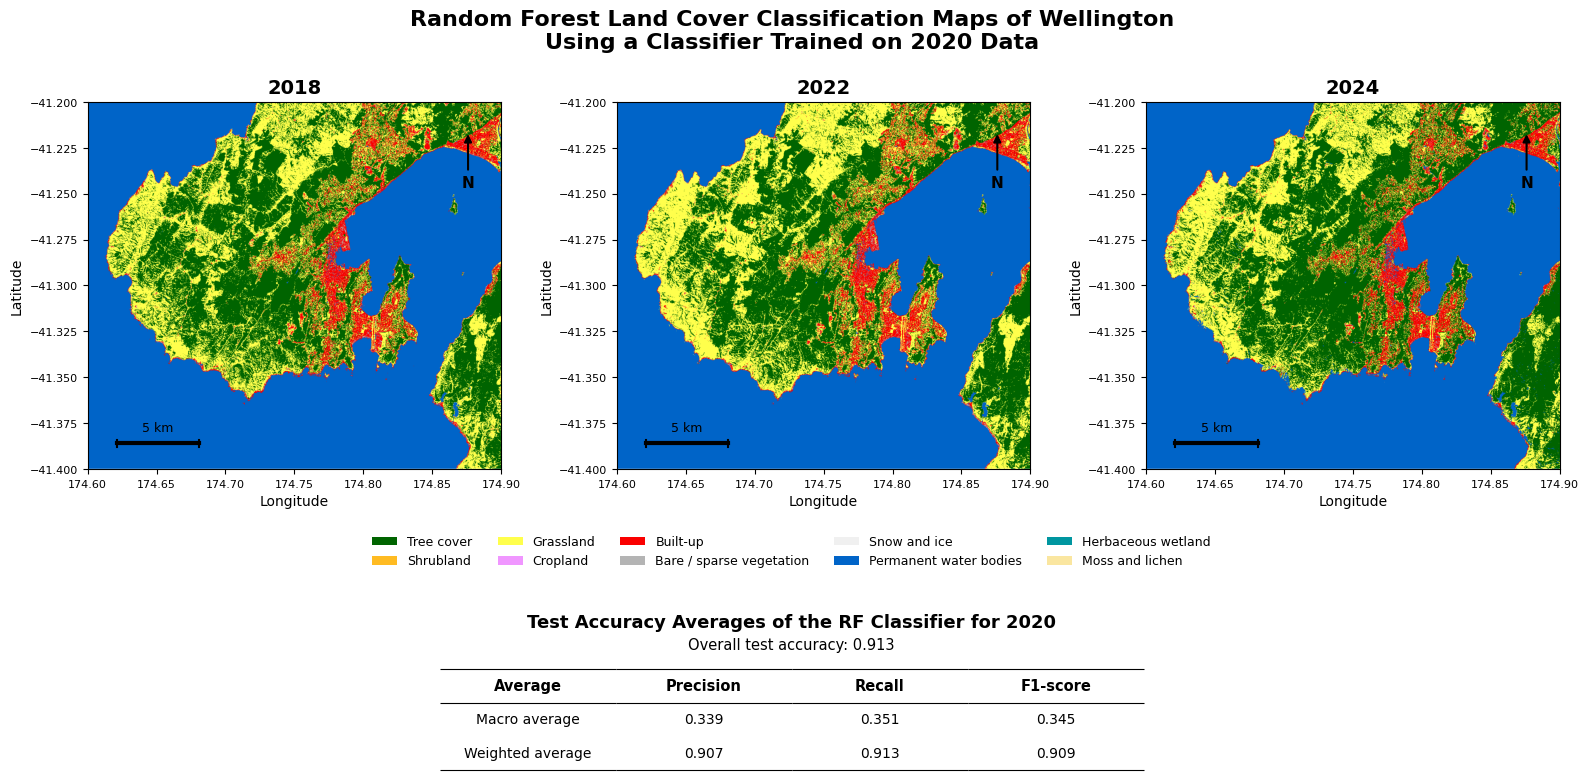

Figure 1. Random Forest land cover classifications of Wellington for 2018, 2022, and 2024, produced by applying a classifier trained using 2020 Sentinel-2 spectral bands (B2, B3, B4, and B8) and ESA WorldCover 2020 reference labels. Classification accuracy is only for 2020 because the matched reference land cover data used for RF model training are from 2020. The accuracy of the 2018, 2022, and 2024 classifications cannot be determined without independent reference data corresponding to those years.


In [97]:
map_images_q5 = [image_2018_q5, image_2022_q5, image_2024_q5]
map_years_q5 = [2018, 2022, 2024]

# Create figure
figure_q5, axes_q5 = plt.subplots(nrows=1, ncols=3, figsize=(16, 8.5))

for axis_q5, map_image_q5, map_year_q5 in zip(
    axes_q5,
    map_images_q5,
    map_years_q5
):
    axis_q5.imshow(map_image_q5, extent=extent_q5, origin='upper')
    mean_latitude_q5 = (extent_q5[2] + extent_q5[3]) / 2
    axis_q5.set_aspect(1 / np.cos(np.deg2rad(mean_latitude_q5)))
    axis_q5.set_title(f'{map_year_q5}', fontsize=14, fontweight='bold')
    axis_q5.set_xlabel('Longitude', fontsize=10)
    axis_q5.set_ylabel('Latitude', fontsize=10)
    axis_q5.tick_params(labelsize=8)
    add_map_elements_q5(axis_q5)

# Main title
figure_q5.suptitle(
    'Random Forest Land Cover Classification Maps of Wellington\n'
    'Using a Classifier Trained on 2020 Data',
    fontsize=16,
    fontweight='bold',
    y=0.94
)

# Shared land cover legend
figure_q5.legend(
    handles=legend_handles_q5,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.27),
    ncol=5,
    frameon=False,
    fontsize=9
)

# Performance table
performance_table_data_q5 = [
    [
        'Macro average',
        f'{macro_precision_q5:.3f}',
        f'{macro_recall_q5:.3f}',
        f'{macro_f1_q5:.3f}'
    ],
    [
        'Weighted average',
        f'{weighted_precision_q5:.3f}',
        f'{weighted_recall_q5:.3f}',
        f'{weighted_f1_q5:.3f}'
    ]
]

performance_column_labels_q5 = [
    'Average',
    'Precision',
    'Recall',
    'F1-score'
]

table_axis_q5 = figure_q5.add_axes([
    0.28,
    0.045,
    0.44,
    0.145
])

table_axis_q5.axis('off')

table_axis_q5.text(
    0.5,
    1.20,
    'Test Accuracy Averages of the RF Classifier for 2020',
    ha='center',
    va='center',
    fontsize=13,
    fontweight='bold',
    transform=table_axis_q5.transAxes
)

table_axis_q5.text(
    0.5,
    1.02,
    f'Overall test accuracy: {accuracy_q5:.3f}',
    ha='center',
    va='center',
    fontsize=10.5,
    transform=table_axis_q5.transAxes
)

performance_table_q5 = table_axis_q5.table(
    cellText=performance_table_data_q5,
    colLabels=performance_column_labels_q5,
    cellLoc='center',
    colLoc='center',
    loc='center',
    bbox=[0, 0, 1, 0.82]
)

performance_table_q5.auto_set_font_size(False)
performance_table_q5.set_fontsize(10)

cells_q5 = performance_table_q5.get_celld()

for (row_q5, col_q5), cell_q5 in cells_q5.items():
    cell_q5.set_facecolor('white')
    cell_q5.set_edgecolor('black')
    cell_q5.set_linewidth(0)
    cell_q5.visible_edges = ''

    if row_q5 == 0:
        cell_q5.set_text_props(
            fontweight='bold',
            fontsize=10.5
        )

for col_q5 in range(4):
    cells_q5[(0, col_q5)].visible_edges = 'TB'
    cells_q5[(0, col_q5)].set_linewidth(0.8)

for col_q5 in range(4):
    cells_q5[(2, col_q5)].visible_edges = 'B'
    cells_q5[(2, col_q5)].set_linewidth(0.8)

performance_table_q5.scale(1.0, 1.35)

plt.subplots_adjust(
    top=0.84,
    bottom=0.39,
    left=0.06,
    right=0.98,
    wspace=0.28
)

# Generate a figure caption
caption_q5 = (
    'Figure 1. Random Forest land cover classifications of Wellington '
    'for 2018, 2022, and 2024, produced by applying a classifier trained '
    'using 2020 Sentinel-2 spectral bands (B2, B3, B4, and B8) and '
    'ESA WorldCover 2020 reference labels. '
    'Classification accuracy is only for 2020 because the matched reference '
    'land cover data used for RF model training are from 2020. '
    'The accuracy of the 2018, 2022, and 2024 classifications cannot be '
    'determined without independent reference data corresponding to those years.'
)

plt.show()
print(caption_q5)